# 07 — GPU providers

Verify CUDA is actually used, measure throughput, and check numerical parity with CPU.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "tests").exists():
    ROOT = ROOT.parent
AUDIO_DIR = ROOT / "tests" / "fixtures" / "audio"
GOLDEN_DIR = ROOT / "tests" / "fixtures" / "golden"
print("project root:", ROOT)


project root: /home/anton/Projects/music-teacher


In [2]:
from music_teacher.transcription.device import available_providers, describe, prepare_runtime

prepare_runtime()
print("available:", available_providers())
print(describe("auto"))


available: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
{'requested': 'auto', 'available': ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider'], 'selected': ['CUDAExecutionProvider', 'CPUExecutionProvider']}


In [3]:
import time
from music_teacher.transcription.audio import load_audio
from music_teacher.transcription.onnx_engine import BasicPitchEngine

audio = load_audio(AUDIO_DIR / "flute_melody.wav")
outputs, timings = {}, {}
for device in ("cpu", "cuda"):
    if device == "cuda" and "CUDAExecutionProvider" not in available_providers():
        print("CUDA unavailable"); continue
    engine = BasicPitchEngine(device=device)
    engine.warmup()
    engine.predict(audio)
    runs = []
    for _ in range(10):
        start = time.perf_counter(); engine.predict(audio); runs.append(time.perf_counter() - start)
    outputs[device] = engine.predict(audio)
    timings[device] = runs
    print(f"{device}: median {np.median(runs) * 1000:.1f} ms  min {min(runs) * 1000:.1f} ms")


cpu: median 31.1 ms  min 30.2 ms


cuda: median 4.0 ms  min 3.9 ms


note     max|diff| = 0.000353  mean = 0.00000720
onset    max|diff| = 0.000761  mean = 0.00002968
contour  max|diff| = 0.000321  mean = 0.00001415


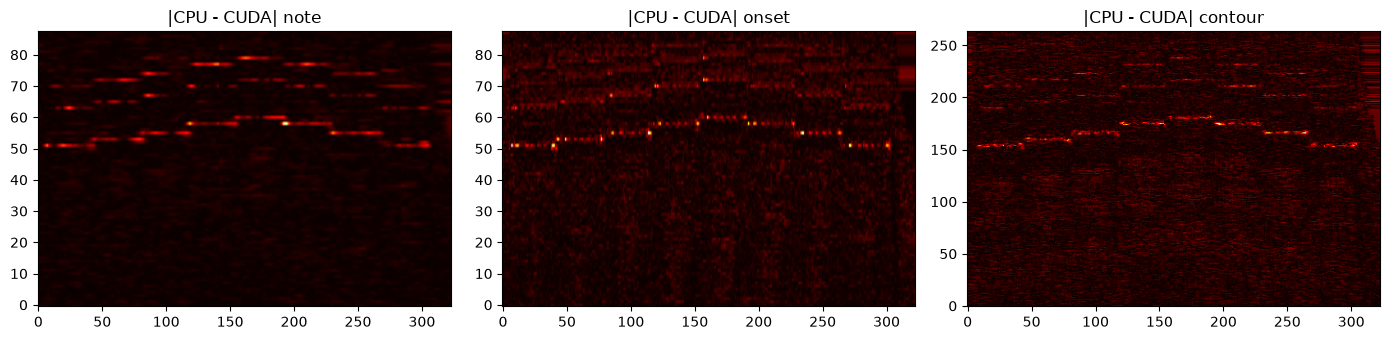

In [4]:
if "cpu" in outputs and "cuda" in outputs:
    for key in ("note", "onset", "contour"):
        diff = np.abs(outputs["cpu"][key] - outputs["cuda"][key])
        print(f"{key:8} max|diff| = {diff.max():.6f}  mean = {diff.mean():.8f}")
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    for ax, key in zip(axes, ("note", "onset", "contour")):
        ax.imshow(np.abs(outputs["cpu"][key] - outputs["cuda"][key]).T, origin="lower", aspect="auto", cmap="hot")
        ax.set_title(f"|CPU - CUDA| {key}")
    fig.tight_layout()


GPU is optional: `device = "auto"` falls back to CPU when CUDA/cuDNN is unavailable. `scripts/bench_gpu.py` is the command-line version of this notebook.